In [11]:
# ============================================================
# Cell 1 - Imports & Reproducibility
# ============================================================

import os
import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision import models

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print(f"PyTorch Version : {torch.__version__}")
print(f"Device          : {device}")
print("=" * 60)

PyTorch Version : 2.11.0+cu128
Device          : cuda


In [12]:
# ============================================================
# Cell 2 - Download & Extract Dataset
# ============================================================

import os
import zipfile
import subprocess
from pathlib import Path

DATA_ROOT = Path("/content/HER2_Dataset")
DATA_ROOT.mkdir(exist_ok=True)

ZIP_PATH = DATA_ROOT / "her2-ihc-40x-wsi.zip"

URL = "https://zenodo.org/records/15179608/files/her2-ihc-40x-wsi.zip?download=1"

# ------------------------------------------------------------
# Download dataset (only if not already downloaded)
# ------------------------------------------------------------

if not ZIP_PATH.exists():
    print("Downloading HER2-IHC-40x dataset...")
    subprocess.run([
        "wget",
        "-O",
        str(ZIP_PATH),
        URL
    ], check=True)
else:
    print("Dataset archive already exists.")

# ------------------------------------------------------------
# Extract main archive
# ------------------------------------------------------------

WSI_DIR = DATA_ROOT / "WSI-based-dataset"

if not WSI_DIR.exists():
    print("Extracting main archive...")

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_ROOT)

    print("Main archive extracted.")

else:
    print("Main archive already extracted.")

# ------------------------------------------------------------
# Extract nested train/test archives
# ------------------------------------------------------------

nested_archives = [
    WSI_DIR / "train_data_wsi.zip",
    WSI_DIR / "test_data_wsi.zip",
]

for archive in nested_archives:

    extract_folder = archive.parent / archive.stem.replace("_data_wsi", "")

    if extract_folder.exists():
        print(f"{extract_folder.name} already extracted.")
        continue

    print(f"Extracting {archive.name}...")

    with zipfile.ZipFile(archive, "r") as z:
        z.extractall(extract_folder)

# ------------------------------------------------------------
# Remove zip archives to save disk space
# ------------------------------------------------------------

for archive in [ZIP_PATH] + nested_archives:
    if archive.exists():
        archive.unlink()

print("ZIP files removed.")

# ------------------------------------------------------------
# Dataset paths
# ------------------------------------------------------------

TRAIN_DIR = WSI_DIR / "train"
TEST_DIR = WSI_DIR / "test"

print("\nDataset location:")
print(TRAIN_DIR)
print(TEST_DIR)

assert TRAIN_DIR.exists(), "Train directory not found."
assert TEST_DIR.exists(), "Test directory not found."

print("\nDataset successfully prepared!")

# ------------------------------------------------------------
# Show directory structure
# ------------------------------------------------------------

print("\nFolder structure:")

for folder in [TRAIN_DIR, TEST_DIR]:
    print(f"\n{folder.name}/")

    for cls in sorted(os.listdir(folder)):
        cls_path = folder / cls
        if cls_path.is_dir():
            n = len(os.listdir(cls_path))
            print(f"   {cls:<10} {n:5d} images")

Main archive already extracted.
train already extracted.
test already extracted.
ZIP files removed.

Dataset location:
/content/HER2_Dataset/WSI-based-dataset/train
/content/HER2_Dataset/WSI-based-dataset/test

Dataset successfully prepared!

Folder structure:

train/
   class_0     3131 images
   class_1+    1837 images
   class_2+     523 images
   class_3+    2602 images

test/
   class_0      658 images
   class_1+     316 images
   class_2+     111 images
   class_3+     762 images


In [13]:
# ============================================================
# Cell 3 - HER2 Dataset
# ============================================================

class HER2Dataset(Dataset):
    """
    HER2-IHC-40x Dataset

    Expected directory structure:

    train/
        class_0/
        class_1+/
        class_2+/
        class_3+

    test/
        class_0/
        class_1+/
        class_2+/
        class_3+
    """

    EXPECTED_CLASSES = [
        "class_0",
        "class_1+",
        "class_2+",
        "class_3+"
    ]

    IMAGE_EXTENSIONS = {
        ".png",
        ".jpg",
        ".jpeg"
    }

    def __init__(self, root_dir, transform=None):

        self.root_dir = Path(root_dir)
        self.transform = transform

        if not self.root_dir.exists():
            raise FileNotFoundError(
                f"Directory not found:\n{self.root_dir}"
            )

        # ----------------------------------------------------
        # Verify class folders
        # ----------------------------------------------------

        self.classes = sorted([
            d.name
            for d in self.root_dir.iterdir()
            if d.is_dir() and not d.name.startswith(".")
        ])

        if self.classes != self.EXPECTED_CLASSES:
            raise ValueError(
                f"Expected folders:\n"
                f"{self.EXPECTED_CLASSES}\n\n"
                f"Found:\n"
                f"{self.classes}"
            )

        self.class_to_idx = {
            cls: idx
            for idx, cls in enumerate(self.classes)
        }

        self.idx_to_class = {
            idx: cls
            for cls, idx in self.class_to_idx.items()
        }

        # ----------------------------------------------------
        # Collect image paths
        # ----------------------------------------------------

        self.samples = []

        for cls in self.classes:

            class_dir = self.root_dir / cls

            images = sorted([
                p
                for p in class_dir.iterdir()
                if p.suffix.lower() in self.IMAGE_EXTENSIONS
            ])

            if len(images) == 0:
                raise RuntimeError(
                    f"No images found in {class_dir}"
                )

            label = self.class_to_idx[cls]

            for img_path in images:
                self.samples.append(
                    (img_path, label)
                )

        print(f"Loaded {len(self.samples)} images from {self.root_dir.name}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        img_path, label = self.samples[index]

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

    def get_num_classes(self):
        return len(self.classes)

    def get_class_names(self):
        return self.classes

    def get_class_distribution(self):

        distribution = {
            cls: 0
            for cls in self.classes
        }

        for _, label in self.samples:
            cls = self.idx_to_class[label]
            distribution[cls] += 1

        return distribution

In [14]:
# ============================================================
# Cell 4 - Image Transforms
# ============================================================

# ImageNet normalization (DenseNet121 is ImageNet pretrained)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ------------------------------------------------------------
# Training Transform
# Paper:
# Resize
# Horizontal Flip
# Vertical Flip
# Rotation
# Normalization
# ------------------------------------------------------------

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomVerticalFlip(p=0.5),

    transforms.RandomRotation(
        degrees=10,
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# ------------------------------------------------------------
# Validation / Test Transform
# No augmentation
# ------------------------------------------------------------

test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Transforms created successfully.")

Transforms created successfully.


In [15]:
# ==========================================================
# Cell 6 — Model (Stage 1)
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# ----------------------------------------------------------
# Load ImageNet pretrained DenseNet121
# ----------------------------------------------------------

model = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

# ----------------------------------------------------------
# Replace classifier
# Paper only specifies replacing the classifier with
# a 4-class output layer.
# ----------------------------------------------------------

num_features = model.classifier.in_features

model.classifier = nn.Linear(num_features, 4)

model = model.to(device)

# ----------------------------------------------------------
# Stage 1
# Freeze DenseNet backbone
# Train ONLY classifier
# ----------------------------------------------------------

for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

print("Stage 1 configuration")
print("---------------------")
print("Backbone : Frozen")
print("Classifier : Trainable")

# ----------------------------------------------------------
# Loss
# ----------------------------------------------------------

criterion = nn.CrossEntropyLoss()

# ----------------------------------------------------------
# Optimizer
# Paper:
# Adam
# LR = 1e-4
# ----------------------------------------------------------

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=1e-4
)

# ----------------------------------------------------------
# Cosine Annealing Scheduler
# Paper:
# Cosine Annealing
# 30 epochs
# ----------------------------------------------------------

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

print("\nModel initialized successfully.")

print(model)

Stage 1 configuration
---------------------
Backbone : Frozen
Classifier : Trainable

Model initialized successfully.
DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _Dens

In [16]:
# ============================================================
# Cell 7 - Training & Evaluation Functions
# ============================================================

from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# Train one epoch
# ------------------------------------------------------------

def train_one_epoch(model, dataloader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc


# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

def evaluate(model, dataloader, criterion):

    model.eval()

    running_loss = 0.0

    preds_all = []
    labels_all = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    epoch_acc = accuracy_score(labels_all, preds_all) * 100

    return (
        epoch_loss,
        epoch_acc,
        preds_all,
        labels_all
    )

In [18]:
# ============================================================
# Create datasets
# ============================================================

train_dataset = HER2Dataset(
    root_dir=TRAIN_DIR,
    transform=train_transform
)

val_dataset = HER2Dataset(
    root_dir=TEST_DIR,
    transform=test_transform
)

print("Train images :", len(train_dataset))
print("Validation images :", len(val_dataset))

Loaded 8093 images from train
Loaded 1847 images from test
Train images : 8093
Validation images : 1847


In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(len(train_loader), len(val_loader))

253 58


In [20]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 253
Validation batches: 58


In [21]:
# ============================================================
# CELL 7 — STAGE 1 : Train Classifier Only
# ============================================================

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Only classifier is trainable
optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

criterion = nn.CrossEntropyLoss()

stage1_epochs = 30

best_acc = 0.0

print("=" * 60)
print("Stage 1")
print("Training classifier only")
print("=" * 60)

for epoch in range(stage1_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc, preds, labels = evaluate(
        model,
        val_loader,
        criterion
    )

    scheduler.step()

    print(
        f"Epoch [{epoch+1:02d}/{stage1_epochs}] | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.2f}% | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.2f}%"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_stage1.pth"
        )

print("\nBest Stage 1 Accuracy:", f"{best_acc:.2f}%")

Stage 1
Training classifier only
Epoch [01/30] | Train Loss 0.8805 | Train Acc 71.47% | Val Loss 0.5975 | Val Acc 83.97%
Epoch [02/30] | Train Loss 0.5517 | Train Acc 83.26% | Val Loss 0.4389 | Val Acc 87.01%
Epoch [03/30] | Train Loss 0.4457 | Train Acc 85.42% | Val Loss 0.3814 | Val Acc 88.79%
Epoch [04/30] | Train Loss 0.3921 | Train Acc 87.09% | Val Loss 0.3200 | Val Acc 90.58%
Epoch [05/30] | Train Loss 0.3497 | Train Acc 88.47% | Val Loss 0.3029 | Val Acc 91.17%
Epoch [06/30] | Train Loss 0.3313 | Train Acc 89.09% | Val Loss 0.2879 | Val Acc 91.88%
Epoch [07/30] | Train Loss 0.3113 | Train Acc 89.86% | Val Loss 0.2796 | Val Acc 91.39%
Epoch [08/30] | Train Loss 0.2901 | Train Acc 90.49% | Val Loss 0.2714 | Val Acc 91.93%
Epoch [09/30] | Train Loss 0.2870 | Train Acc 90.54% | Val Loss 0.2745 | Val Acc 90.96%
Epoch [10/30] | Train Loss 0.2755 | Train Acc 90.89% | Val Loss 0.2396 | Val Acc 92.47%
Epoch [11/30] | Train Loss 0.2718 | Train Acc 90.49% | Val Loss 0.2456 | Val Acc 92.31%

In [22]:
# ============================================================
# Save Best Stage 1 Model to Google Drive
# ============================================================

from google.colab import drive
import os
import shutil

# Mount Drive (if not already mounted)
drive.mount('/content/drive')

# -------- Local checkpoint --------
LOCAL_MODEL = "/content/best_stage1.pth"   # <-- change if your filename is different

# -------- Destination --------
SAVE_DIR = "/content/drive/MyDrive/HER2_Checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

DEST_MODEL = os.path.join(SAVE_DIR, "best_stage1.pth")

if os.path.exists(LOCAL_MODEL):
    shutil.copy2(LOCAL_MODEL, DEST_MODEL)

    print("✅ Stage 1 model saved successfully!")
    print(f"Saved to:\n{DEST_MODEL}")

    size_mb = os.path.getsize(DEST_MODEL) / 1024 / 1024
    print(f"Model size: {size_mb:.2f} MB")

else:
    print("❌ Stage 1 checkpoint not found.")
    print(f"Expected path:\n{LOCAL_MODEL}")

Mounted at /content/drive
✅ Stage 1 model saved successfully!
Saved to:
/content/drive/MyDrive/HER2_Checkpoints/best_stage1.pth
Model size: 27.12 MB


In [24]:
import os
import shutil
from datetime import datetime

# ============================================================
# Save Stage 1
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/HER2_Checkpoints/Stage1"
os.makedirs(SAVE_DIR, exist_ok=True)

checkpoint_path = os.path.join(SAVE_DIR, "stage1_checkpoint.pth")
report_path = os.path.join(SAVE_DIR, "stage1_summary.txt")

# ------------------------------------------------------------
# Save complete checkpoint
# ------------------------------------------------------------
torch.save({
    "stage": 1,
    "epoch": stage1_epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "best_val_accuracy": best_acc,
    "model_name": "DenseNet121",
    "pretrained": True,
    "num_classes": 4
}, checkpoint_path)

print(f"Checkpoint saved to:\n{checkpoint_path}")

# ------------------------------------------------------------
# Create documentation
# ------------------------------------------------------------

summary = f"""
=========================================================
HER2-IHC-40x
Stage 1 Training Summary
=========================================================

Date:
{datetime.now()}

---------------------------------------------------------
Model
---------------------------------------------------------

Backbone:
DenseNet121

Pretrained:
ImageNet

Number of classes:
4

---------------------------------------------------------
Training strategy
---------------------------------------------------------

Stage:
1

Description:
Feature extractor frozen.
Only classifier trained.

---------------------------------------------------------
Dataset
---------------------------------------------------------

Training images:
8093

Testing images:
1847

Classes:
0
1+
2+
3+

---------------------------------------------------------
Input
---------------------------------------------------------

Input size:
224 x 224

---------------------------------------------------------
Augmentations
---------------------------------------------------------

Resize(224)

RandomHorizontalFlip

RandomVerticalFlip

RandomRotation

Normalize(ImageNet)

---------------------------------------------------------
Optimizer
---------------------------------------------------------

Adam

Learning rate:
0.0001

Loss:
CrossEntropyLoss

Scheduler:
Cosine Annealing

Batch size:
32

Epochs:
{stage1_epochs}

---------------------------------------------------------
Results
---------------------------------------------------------

Best Validation Accuracy:

{best_acc:.4f}

---------------------------------------------------------
Checkpoint

File:
stage1_checkpoint.pth

=========================================================
"""

with open(report_path, "w") as f:
    f.write(summary)

print(f"Summary saved to:\n{report_path}")

Checkpoint saved to:
/content/drive/MyDrive/HER2_Checkpoints/Stage1/stage1_checkpoint.pth
Summary saved to:
/content/drive/MyDrive/HER2_Checkpoints/Stage1/stage1_summary.txt


# stage 2

In [29]:
import torch

def validate_one_epoch(
    model,
    dataloader,
    criterion
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

In [25]:
# ============================================================
# Stage 2
# Fine-tune the entire DenseNet
# ============================================================

print("=" * 60)
print("Stage 2")
print("Fine-tuning entire DenseNet")
print("=" * 60)

# ------------------------------------------------------------
# Unfreeze the entire network
# ------------------------------------------------------------
for param in model.parameters():
    param.requires_grad = True

# ------------------------------------------------------------
# Discriminative learning rates
# ------------------------------------------------------------
BACKBONE_LR = 1e-5
CLASSIFIER_LR = 1e-4

optimizer = torch.optim.Adam(
    [
        {
            "params": model.features.parameters(),
            "lr": BACKBONE_LR
        },
        {
            "params": model.classifier.parameters(),
            "lr": CLASSIFIER_LR
        }
    ]
)

# ------------------------------------------------------------
# Cosine Annealing Scheduler
# ------------------------------------------------------------
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

criterion = nn.CrossEntropyLoss()

stage2_epochs = 30

best_stage2_acc = 0.0

print("\nStage 2 configuration")
print("-" * 40)
print(f"Backbone LR   : {BACKBONE_LR}")
print(f"Classifier LR : {CLASSIFIER_LR}")
print(f"Epochs        : {stage2_epochs}")
print(f"Scheduler     : CosineAnnealingLR")
print(f"Loss          : CrossEntropyLoss")
print("\n✓ Entire DenseNet unfrozen.")

Stage 2
Fine-tuning entire DenseNet

Stage 2 configuration
----------------------------------------
Backbone LR   : 1e-05
Classifier LR : 0.0001
Epochs        : 30
Scheduler     : CosineAnnealingLR
Loss          : CrossEntropyLoss

✓ Entire DenseNet unfrozen.


In [32]:
# ============================================================
# Stage 2
# Load Best Stage 1 + Fine-tune Entire DenseNet
# ============================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim

print("=" * 60)
print("Stage 2")
print("Fine-tuning entire DenseNet")
print("=" * 60)

# ------------------------------------------------------------
# Load the BEST Stage 1 checkpoint
# ------------------------------------------------------------

stage1_checkpoint = "/content/drive/MyDrive/HER2_Checkpoints/Stage1/stage1_checkpoint.pth"

if not os.path.exists(stage1_checkpoint):
    raise FileNotFoundError(f"Stage 1 checkpoint not found:\n{stage1_checkpoint}")

checkpoint = torch.load(stage1_checkpoint, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])

print("\nLoaded Stage 1 checkpoint")
print("-" * 40)
print(f"Stage            : {checkpoint['stage']}")
print(f"Epoch            : {checkpoint['epoch']}")
print(f"Best Validation  : {checkpoint['best_val_accuracy']:.2f}%")

# ------------------------------------------------------------
# Unfreeze the ENTIRE DenseNet
# ------------------------------------------------------------

for param in model.parameters():
    param.requires_grad = True

# ------------------------------------------------------------
# Stage 2 Hyperparameters
# ------------------------------------------------------------

BACKBONE_LR = 1e-5
CLASSIFIER_LR = 1e-4

optimizer = optim.Adam(
    [
        {
            "params": model.features.parameters(),
            "lr": BACKBONE_LR,
        },
        {
            "params": model.classifier.parameters(),
            "lr": CLASSIFIER_LR,
        },
    ]
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

criterion = nn.CrossEntropyLoss()

stage2_epochs = 30

# Stage 2 should improve over Stage 1
best_stage2_acc = checkpoint["best_val_accuracy"]

print("\nStage 2 configuration")
print("-" * 40)
print(f"Backbone LR      : {BACKBONE_LR}")
print(f"Classifier LR    : {CLASSIFIER_LR}")
print(f"Epochs           : {stage2_epochs}")
print(f"Scheduler        : CosineAnnealingLR")
print(f"Starting Acc     : {best_stage2_acc:.2f}%")

print("\nStarting Stage 2 Fine-Tuning...\n")

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

for epoch in range(stage2_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
    )

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
    )

    scheduler.step()

    print(
        f"Epoch [{epoch+1:02d}/{stage2_epochs}] | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.2f}% | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.2f}%"
    )

    if val_acc > best_stage2_acc:

        best_stage2_acc = val_acc

        torch.save(
            {
                "stage": 2,
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_accuracy": best_stage2_acc,
                "config": {
                    "backbone": "DenseNet121",
                    "pretrained": True,
                    "backbone_lr": BACKBONE_LR,
                    "classifier_lr": CLASSIFIER_LR,
                    "batch_size": BATCH_SIZE,
                    "epochs": stage2_epochs,
                },
            },
            "/content/best_stage2_model.pth",
        )

        print(f"✓ New best Stage 2 model saved ({best_stage2_acc:.2f}%)")

print("\n" + "=" * 60)
print(f"Best Stage 2 Accuracy : {best_stage2_acc:.2f}%")
print("=" * 60)

Stage 2
Fine-tuning entire DenseNet

Loaded Stage 1 checkpoint
----------------------------------------
Stage            : 1
Epoch            : 30
Best Validation  : 92.64%

Stage 2 configuration
----------------------------------------
Backbone LR      : 1e-05
Classifier LR    : 0.0001
Epochs           : 30
Scheduler        : CosineAnnealingLR
Starting Acc     : 92.64%

Starting Stage 2 Fine-Tuning...

Epoch [01/30] | Train Loss 0.1845 | Train Acc 93.77% | Val Loss 0.1706 | Val Acc 93.23%
✓ New best Stage 2 model saved (93.23%)
Epoch [02/30] | Train Loss 0.1389 | Train Acc 95.02% | Val Loss 0.1626 | Val Acc 93.83%
✓ New best Stage 2 model saved (93.83%)
Epoch [03/30] | Train Loss 0.1059 | Train Acc 96.35% | Val Loss 0.1456 | Val Acc 94.21%
✓ New best Stage 2 model saved (94.21%)
Epoch [04/30] | Train Loss 0.0883 | Train Acc 97.08% | Val Loss 0.1466 | Val Acc 93.83%
Epoch [05/30] | Train Loss 0.0852 | Train Acc 97.01% | Val Loss 0.1249 | Val Acc 94.59%
✓ New best Stage 2 model saved (9

In [33]:
# ============================================================
# Save Stage 2 Artifacts
# ============================================================

import os
import shutil
from datetime import datetime
import torch

# ------------------------------------------------------------
# Create folder
# ------------------------------------------------------------

stage2_dir = "/content/drive/MyDrive/HER2_Checkpoints/Stage2"
os.makedirs(stage2_dir, exist_ok=True)

# ------------------------------------------------------------
# Save checkpoint
# ------------------------------------------------------------

checkpoint_src = "/content/best_stage2_model.pth"
checkpoint_dst = os.path.join(stage2_dir, "stage2_checkpoint.pth")

shutil.copy(checkpoint_src, checkpoint_dst)

# ------------------------------------------------------------
# Save model weights only
# ------------------------------------------------------------

weights_path = os.path.join(stage2_dir, "stage2_weights.pth")

torch.save(
    model.state_dict(),
    weights_path
)

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

summary = f"""
============================================================
HER2-IHC-40x
Stage 2 Training Summary
============================================================

Date
----
{datetime.now()}

Backbone
--------
DenseNet121 (ImageNet Pretrained)

Training Strategy
-----------------
Stage 1:
    Freeze backbone
    Train classifier

Stage 2:
    Unfreeze entire DenseNet
    Fine-tune whole network

Optimizer
---------
Adam

Learning Rates
--------------
Backbone LR   : 1e-5
Classifier LR : 1e-4

Scheduler
---------
CosineAnnealingLR

Loss
----
CrossEntropyLoss

Batch Size
----------
{BATCH_SIZE}

Epochs
------
{stage2_epochs}

Best Validation Accuracy
------------------------
{best_stage2_acc:.2f} %

Dataset
-------
HER2-IHC-40x (WSI Split)

Classes
-------
0
1+
2+
3+

Saved Files
-----------
stage2_checkpoint.pth
stage2_weights.pth
stage2_summary.txt

============================================================
"""

summary_path = os.path.join(stage2_dir, "stage2_summary.txt")

with open(summary_path, "w") as f:
    f.write(summary)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 60)
print("Stage 2 artifacts saved successfully!")
print("=" * 60)

print(f"Checkpoint : {checkpoint_dst}")
print(f"Weights    : {weights_path}")
print(f"Summary    : {summary_path}")
print(f"Best Accuracy : {best_stage2_acc:.2f}%")

Stage 2 artifacts saved successfully!
Checkpoint : /content/drive/MyDrive/HER2_Checkpoints/Stage2/stage2_checkpoint.pth
Weights    : /content/drive/MyDrive/HER2_Checkpoints/Stage2/stage2_weights.pth
Summary    : /content/drive/MyDrive/HER2_Checkpoints/Stage2/stage2_summary.txt
Best Accuracy : 94.64%


In [34]:
# ============================================================
# Final Evaluation (Best Stage 2 Model)
# ============================================================

import os
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Load best Stage 2 checkpoint
# ------------------------------------------------------------

stage2_checkpoint = "/content/drive/MyDrive/HER2_Checkpoints/Stage2/stage2_checkpoint.pth"

if not os.path.exists(stage2_checkpoint):
    raise FileNotFoundError(stage2_checkpoint)

checkpoint = torch.load(stage2_checkpoint, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("="*60)
print("Loaded Best Stage 2 Model")
print(f"Validation Accuracy : {checkpoint['best_val_accuracy']:.2f}%")
print("="*60)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(all_labels, all_predictions)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    average="weighted"
)

print("\nFinal Results")
print("-"*40)
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

class_names = ["0", "1+", "2+", "3+"]

print("\nClassification Report")
print("-"*40)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(all_labels, all_predictions)

print("\nConfusion Matrix")
print("-"*40)
print(cm)

Loaded Best Stage 2 Model
Validation Accuracy : 94.64%

Final Results
----------------------------------------
Accuracy : 94.64%
Precision: 0.9487
Recall   : 0.9464
F1 Score : 0.9464

Classification Report
----------------------------------------
              precision    recall  f1-score   support

           0     0.9421    0.9635    0.9527       658
          1+     0.9046    0.8101    0.8548       316
          2+     0.7714    0.9730    0.8606       111
          3+     0.9987    0.9843    0.9914       762

    accuracy                         0.9464      1847
   macro avg     0.9042    0.9327    0.9148      1847
weighted avg     0.9487    0.9464    0.9464      1847


Confusion Matrix
----------------------------------------
[[634  24   0   0]
 [ 38 256  22   0]
 [  1   1 108   1]
 [  0   2  10 750]]


In [35]:
# ============================================================
# Final Evaluation (Best Stage 2 Model)
# ============================================================

import os
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Load best Stage 2 checkpoint
# ------------------------------------------------------------

stage2_checkpoint = "/content/drive/MyDrive/HER2_Checkpoints/Stage2/stage2_checkpoint.pth"

if not os.path.exists(stage2_checkpoint):
    raise FileNotFoundError(stage2_checkpoint)

checkpoint = torch.load(stage2_checkpoint, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("="*60)
print("Loaded Best Stage 2 Model")
print(f"Validation Accuracy : {checkpoint['best_val_accuracy']:.2f}%")
print("="*60)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(all_labels, all_predictions)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    average="weighted"
)

print("\nFinal Results")
print("-"*40)
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

class_names = ["0", "1+", "2+", "3+"]

print("\nClassification Report")
print("-"*40)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(all_labels, all_predictions)

print("\nConfusion Matrix")
print("-"*40)
print(cm)

Loaded Best Stage 2 Model
Validation Accuracy : 94.64%

Final Results
----------------------------------------
Accuracy : 94.64%
Precision: 0.9487
Recall   : 0.9464
F1 Score : 0.9464

Classification Report
----------------------------------------
              precision    recall  f1-score   support

           0     0.9421    0.9635    0.9527       658
          1+     0.9046    0.8101    0.8548       316
          2+     0.7714    0.9730    0.8606       111
          3+     0.9987    0.9843    0.9914       762

    accuracy                         0.9464      1847
   macro avg     0.9042    0.9327    0.9148      1847
weighted avg     0.9487    0.9464    0.9464      1847


Confusion Matrix
----------------------------------------
[[634  24   0   0]
 [ 38 256  22   0]
 [  1   1 108   1]
 [  0   2  10 750]]


In [36]:
# ============================================================
# Load Best Stage 2 Model
# ============================================================

import os
import torch

stage2_model_path = "/content/drive/MyDrive/HER2_Checkpoints/Stage2/best_stage2_model.pth"

if not os.path.exists(stage2_model_path):
    raise FileNotFoundError(stage2_model_path)

checkpoint = torch.load(stage2_model_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("="*60)
print("Loaded Best Stage 2 Model")
print("="*60)
print(f"Best Validation Accuracy : {checkpoint['best_val_accuracy']:.2f}%")
print(f"Saved Epoch              : {checkpoint['epoch']}")
print("="*60)

FileNotFoundError: /content/drive/MyDrive/HER2_Checkpoints/Stage2/best_stage2_model.pth

In [37]:
# ============================================================
# Evaluate on Test Set
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(
    all_labels,
    all_preds,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)

cm = confusion_matrix(all_labels, all_preds)

print("="*60)
print("Final Test Results")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

Final Test Results
Accuracy : 0.9464
Precision: 0.9487
Recall   : 0.9464
F1 Score : 0.9464

Classification Report

              precision    recall  f1-score   support

     class_0       0.94      0.96      0.95       658
    class_1+       0.90      0.81      0.85       316
    class_2+       0.77      0.97      0.86       111
    class_3+       1.00      0.98      0.99       762

    accuracy                           0.95      1847
   macro avg       0.90      0.93      0.91      1847
weighted avg       0.95      0.95      0.95      1847



In [38]:
import os

print(os.path.exists("/content/best_stage2_model.pth"))

True


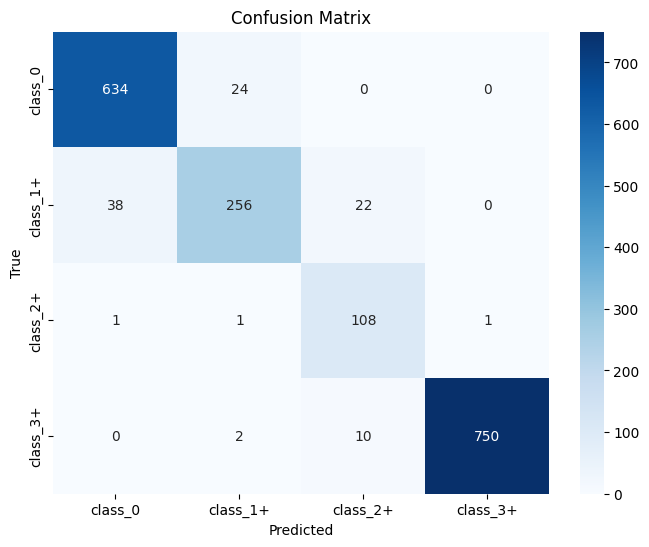

In [39]:
# ============================================================
# Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [40]:
# ============================================================
# Save Complete Experiment Summary
# ============================================================

import os

summary_path = "/content/drive/MyDrive/HER2_Checkpoints/experiment_summary.txt"

with open(summary_path, "w") as f:

    f.write("="*70 + "\n")
    f.write("HER2-IHC DenseNet121 Training Summary\n")
    f.write("="*70 + "\n\n")

    f.write("Dataset\n")
    f.write("------------------------------\n")
    f.write(f"Training images : {len(train_dataset)}\n")
    f.write(f"Testing images  : {len(val_dataset)}\n\n")

    f.write("Model\n")
    f.write("------------------------------\n")
    f.write("Backbone : DenseNet121\n")
    f.write("Pretrained : ImageNet\n")
    f.write("Classes : 4\n\n")

    f.write("Training Strategy\n")
    f.write("------------------------------\n")
    f.write("Stage 1:\n")
    f.write("  Backbone Frozen\n")
    f.write("  Train Classifier Only\n")
    f.write("  Epochs : 30\n")
    f.write("  LR : 1e-4\n")
    f.write(f"  Best Validation Accuracy : {checkpoint['best_val_accuracy']:.2f}%\n\n")

    f.write("Stage 2:\n")
    f.write("  Entire DenseNet Unfrozen\n")
    f.write("  Backbone LR : 1e-5\n")
    f.write("  Classifier LR : 1e-4\n")
    f.write("  Epochs : 30\n")
    f.write(f"  Best Validation Accuracy : {best_stage2_acc:.2f}%\n\n")

    f.write("Data Augmentation\n")
    f.write("------------------------------\n")
    f.write("- Resize 224x224\n")
    f.write("- Random Horizontal Flip\n")
    f.write("- Random Vertical Flip\n")
    f.write("- Random Rotation\n\n")

    f.write("Optimizer\n")
    f.write("------------------------------\n")
    f.write("Adam\n")
    f.write("CosineAnnealingLR\n\n")

    f.write("Final Metrics\n")
    f.write("------------------------------\n")
    f.write(f"Accuracy  : {accuracy:.4f}\n")
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall    : {recall:.4f}\n")
    f.write(f"F1 Score  : {f1:.4f}\n")

print(f"Summary saved to:\n{summary_path}")

Summary saved to:
/content/drive/MyDrive/HER2_Checkpoints/experiment_summary.txt


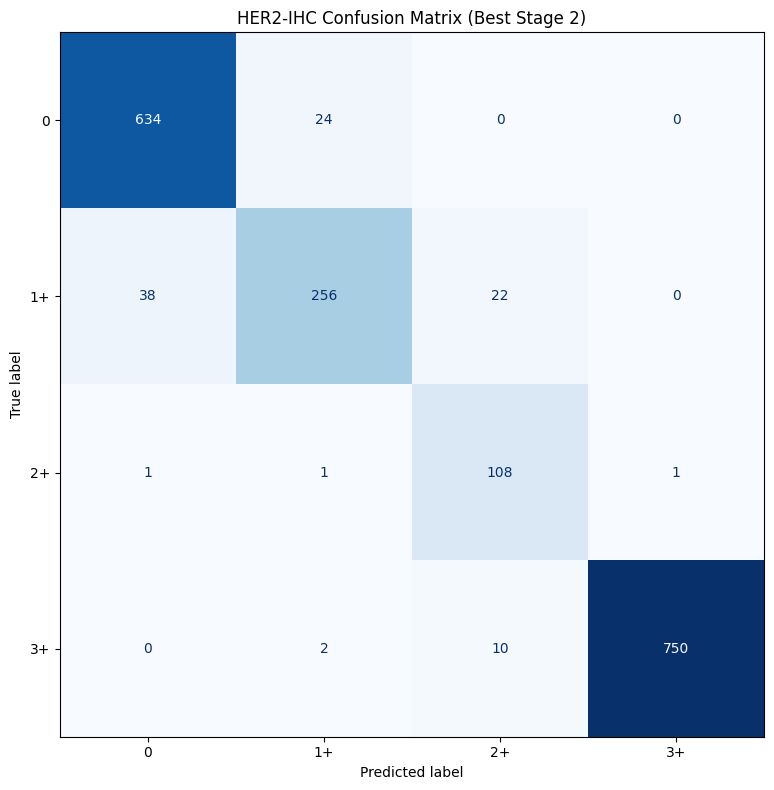


✅ Confusion matrix saved to:
/content/drive/MyDrive/HER2_Checkpoints/Stage2/confusion_matrix_stage2.png


In [41]:
# ============================================================
# Save Confusion Matrix
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------------------
# Directory
# ------------------------------------------------------------

SAVE_DIR = "/content/drive/MyDrive/HER2_Checkpoints/Stage2"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Collect predictions
# ------------------------------------------------------------

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

class_names = ["0", "1+", "2+", "3+"]

cm = confusion_matrix(
    all_labels,
    all_preds
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("HER2-IHC Confusion Matrix (Best Stage 2)")
plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

save_path = os.path.join(
    SAVE_DIR,
    "confusion_matrix_stage2.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\n✅ Confusion matrix saved to:\n{save_path}")


In [42]:
# ============================================================
# Save Classification Report
# ============================================================

import os
import pandas as pd

from sklearn.metrics import classification_report

# ------------------------------------------------------------
# Save directory
# ------------------------------------------------------------

SAVE_DIR = "/content/drive/MyDrive/HER2_Checkpoints/Stage2"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Get predictions
# ------------------------------------------------------------

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

class_names = ["0", "1+", "2+", "3+"]

report_text = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)

report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

# ------------------------------------------------------------
# Print report
# ------------------------------------------------------------

print("=" * 70)
print("Classification Report")
print("=" * 70)
print(report_text)

# ------------------------------------------------------------
# Save TXT
# ------------------------------------------------------------

txt_path = os.path.join(
    SAVE_DIR,
    "classification_report_stage2.txt"
)

with open(txt_path, "w") as f:
    f.write("HER2-IHC Classification Report\n")
    f.write("=" * 70 + "\n\n")
    f.write(report_text)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

csv_path = os.path.join(
    SAVE_DIR,
    "classification_report_stage2.csv"
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(csv_path, index=True)

print("\n✅ Classification report saved.")
print(f"TXT : {txt_path}")
print(f"CSV : {csv_path}")

Classification Report
              precision    recall  f1-score   support

           0     0.9421    0.9635    0.9527       658
          1+     0.9046    0.8101    0.8548       316
          2+     0.7714    0.9730    0.8606       111
          3+     0.9987    0.9843    0.9914       762

    accuracy                         0.9464      1847
   macro avg     0.9042    0.9327    0.9148      1847
weighted avg     0.9487    0.9464    0.9464      1847


✅ Classification report saved.
TXT : /content/drive/MyDrive/HER2_Checkpoints/Stage2/classification_report_stage2.txt
CSV : /content/drive/MyDrive/HER2_Checkpoints/Stage2/classification_report_stage2.csv
